# Eavesdropper Attacks on BB84

Generated from the public notebook builder for reproducible analysis.

Notebook 02 introduces Eve. We add a single function to `src/bb84.py` &mdash; `eve_intercept_resend` &mdash; and use it to verify two of the most quoted BB84 results:

1. **Full intercept-resend produces $\mathrm{QBER} = 25\%$** (not 50%, despite Eve guessing the wrong basis half the time).
2. **QBER is linear in Eve's interception probability:** $\mathrm{QBER}(p) = 0.25\,p$.

We then push to the security threshold and chart the key rate vs. interception probability for two error-correction efficiencies. All values are simulated end-to-end &mdash; nothing is hardcoded.

**Caveat:** every key-rate plot in this notebook uses the *idealized single-photon source model*. Real weak coherent sources are vulnerable to PNS attacks; that is discussed conceptually in Step 3.4 and addressed by decoy states.

## 1. Bootstrap and imports

In [1]:
from pathlib import Path
import sys


def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'src').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise RuntimeError('Could not find project root')


PROJECT_ROOT = find_project_root()
FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\COWLAR\projects\qkd-protocol-simulator


In [2]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from src.bb84 import (
    alice_prepare, bob_measure, sift, estimate_qber,
    error_correction, final_key_length, eve_intercept_resend,
)
from src.info_theory import binary_entropy

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

rng_master = np.random.default_rng(2026)
N = 100_000


## 2. The intercept-resend attack &mdash; QBER = 25%

Eve intercepts every qubit, picks $Z$ or $X$ at random, measures, re-prepares a fresh photon in *her* basis, and forwards it to Bob. The Born rule applies twice:

* Eve's wrong-basis measurement (probability 1/2) gives a uniform   random result.
* Bob's correct-basis measurement of Eve's wrong-basis state has   50% overlap with each eigenstate, so Bob errs with probability   1/2 on those rounds.

$\mathrm{QBER} = P(\text{Eve wrong}) \times P(\text{Bob err} \mid \text{Eve wrong}) = 1/2 \times 1/2 = 1/4$.

In [3]:
rng = np.random.default_rng(2026)

alice_bits, alice_bases = alice_prepare(N, rng=rng)
eve_bits, fwd_bits, fwd_bases, intercepted = eve_intercept_resend(
    alice_bits, alice_bases, interception_rate=1.0, rng=rng,
)
bob_bases = rng.integers(0, 2, N)
bob_bits = bob_measure(fwd_bits, fwd_bases, bob_bases, rng=rng)

alice_sifted, bob_sifted = sift(alice_bits, bob_bits, alice_bases, bob_bases)
qber_full_eve = float(np.mean(alice_sifted != bob_sifted))

print(f'BB84 with full intercept-resend (N = {N:,}, seed = 2026):')
print(f'  Sifted key length : {len(alice_sifted):,}')
print(f'  QBER              : {qber_full_eve:.4f}  (theory 0.2500)')
print(f'  Eve detected ?    : {"YES" if qber_full_eve > 0.05 else "NO"}')


BB84 with full intercept-resend (N = 100,000, seed = 2026):
  Sifted key length : 49,876
  QBER              : 0.2478  (theory 0.2500)
  Eve detected ?    : YES


### 2.1 Comparison: with vs. without Eve

Same seed, same number of pulses &mdash; only Eve's presence changes. The QBER ratio makes Eve impossible to miss.

In [4]:
rng2 = np.random.default_rng(2026)
a2_bits, a2_bases = alice_prepare(N, rng=rng2)
b2_bases = rng2.integers(0, 2, N)
b2_bits = bob_measure(a2_bits, a2_bases, b2_bases, rng=rng2)
a2_s, b2_s = sift(a2_bits, b2_bits, a2_bases, b2_bases)
qber_no_eve = float(np.mean(a2_s != b2_s)) if len(a2_s) > 0 else 0.0

print('Comparison:')
print(f'  No Eve   : QBER = {qber_no_eve:.4f}')
print(f'  Full Eve : QBER = {qber_full_eve:.4f}')
ratio = qber_full_eve / max(qber_no_eve, 1e-10)
print(f'  Ratio    : {ratio:.0f}x')


Comparison:
  No Eve   : QBER = 0.0000
  Full Eve : QBER = 0.2478
  Ratio    : 2477744807x


## 3. QBER vs. interception probability

Sweep Eve's interception probability $p$ from 0 to 1. The expected curve is the straight line $\mathrm{QBER} = 0.25\,p$ &mdash; intercepted qubits each carry an independent 25% error probability and non-intercepted qubits contribute zero error.

In [5]:
interception_rates = np.linspace(0.0, 1.0, 21)
qber_values = []

for p in interception_rates:
    rng_sweep = np.random.default_rng(2026)
    a, ab = alice_prepare(N, rng=rng_sweep)
    _, fwd_b, fwd_ba, _ = eve_intercept_resend(
        a, ab, interception_rate=float(p), rng=rng_sweep,
    )
    bb = rng_sweep.integers(0, 2, N)
    bm = bob_measure(fwd_b, fwd_ba, bb, rng=rng_sweep)
    a_s, b_s = sift(a, bm, ab, bb)
    qber_values.append(float(np.mean(a_s != b_s)) if len(a_s) > 0 else 0.0)

qber_values = np.asarray(qber_values)
for p, q in zip(interception_rates[::4], qber_values[::4]):
    print(f'  p = {p:.2f}  ->  QBER = {q:.4f}  (theory {0.25 * p:.4f})')


  p = 0.00  ->  QBER = 0.0000  (theory 0.0000)
  p = 0.20  ->  QBER = 0.0498  (theory 0.0500)
  p = 0.40  ->  QBER = 0.0991  (theory 0.1000)
  p = 0.60  ->  QBER = 0.1480  (theory 0.1500)
  p = 0.80  ->  QBER = 0.1980  (theory 0.2000)
  p = 1.00  ->  QBER = 0.2478  (theory 0.2500)


### Figure 3 &mdash; QBER vs. interception probability

Saved at 300 dpi as `figures/qber_vs_interception.png`. The horizontal dashed lines mark the BB84 abort thresholds for $f_{ec} = 1$ and $f_{ec} = 1.16$ (computed below).

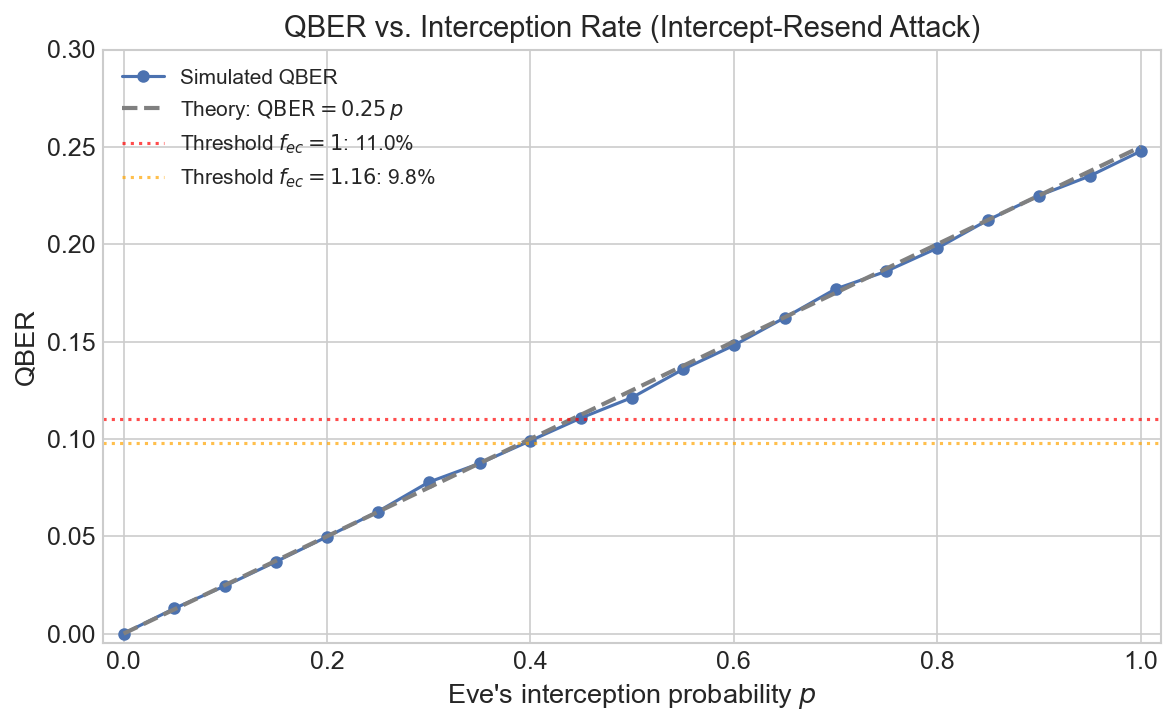

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(interception_rates, qber_values, 'o-', label='Simulated QBER',
        markersize=5, color='#4C72B0')
ax.plot(interception_rates, 0.25 * interception_rates, '--',
        label=r'Theory: $\mathrm{QBER} = 0.25\,p$', color='gray', linewidth=2)
ax.axhline(0.110, color='red', linestyle=':', alpha=0.7,
           label=r'Threshold $f_{ec}=1$: 11.0%')
ax.axhline(0.098, color='orange', linestyle=':', alpha=0.7,
           label=r'Threshold $f_{ec}=1.16$: 9.8%')
ax.set_xlabel(r"Eve's interception probability $p$", fontsize=13)
ax.set_ylabel('QBER', fontsize=13)
ax.set_title('QBER vs. Interception Rate (Intercept-Resend Attack)',
             fontsize=14)
ax.legend(fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.005, 0.30)
plt.tight_layout()
plt.savefig(FIG_DIR / 'qber_vs_interception.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Eve's information gain

On rounds Eve actually intercepted *and* that survive sifting:

* **Correct basis** (probability 1/2): Eve reads Alice's bit   exactly &mdash; 1 bit of information.
* **Wrong basis** (probability 1/2): Eve's outcome is uniform   random &mdash; 0 bits of information, although she still gets   the right bit by chance 50% of the time.

Eve's *raw bit accuracy* on intercepted sifted rounds is therefore $1/2 + 1/2 \times 1/2 = 75\%$, but her *information* content is only $0.5$ bits per intercepted sifted round &mdash; she cannot distinguish certain knowledge from a lucky guess.

In [7]:
rng3 = np.random.default_rng(2026)
a, ab = alice_prepare(N, rng=rng3)
e_bits, fwd_b, fwd_ba, intc = eve_intercept_resend(
    a, ab, interception_rate=1.0, rng=rng3,
)
bb = rng3.integers(0, 2, N)
bob_measure(fwd_b, fwd_ba, bb, rng=rng3)  # advance RNG identically

sifted_mask = ab == bb
sifted_and_intercepted = sifted_mask & intc
eve_correct_rate = float(np.mean(
    e_bits[sifted_and_intercepted] == a[sifted_and_intercepted]
))

print(f"Eve's accuracy on intercepted sifted bits: {eve_correct_rate:.3f}")
print(f'Theoretical expectation                  : 0.750')
print(f'  -- 50% correct-basis (perfect) + 25% wrong-basis lucky')


Eve's accuracy on intercepted sifted bits: 0.753
Theoretical expectation                  : 0.750
  -- 50% correct-basis (perfect) + 25% wrong-basis lucky
